# **Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# **Create Dataset** (Simple Linear Regression)

In [2]:
X, y = make_regression(n_samples=500, n_features=1, noise=40, random_state=42)

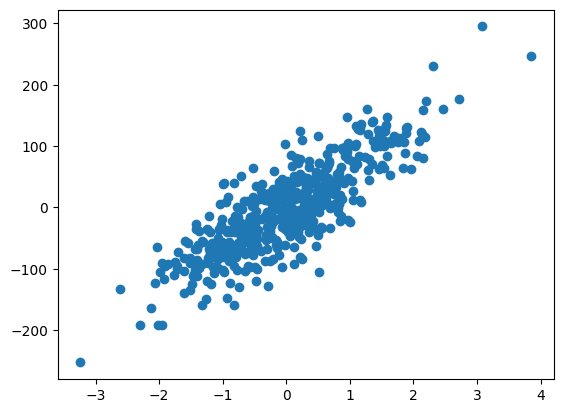

In [3]:
fig = plt.figure()
plt.scatter(X,y)

# **Train Test Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(400, 1)
(400,)
(100, 1)
(100,)


# **Simple Linear Regression**

In [6]:
def model(w, x, b):

  m = len(x)
  y_hat = []

  for i in range(m):
    f_wb = w * x[i] + b
    y_hat.append(f_wb)

  return y_hat


In [7]:
w = 2
b = 1

y_hat = model(w, X_train, b)

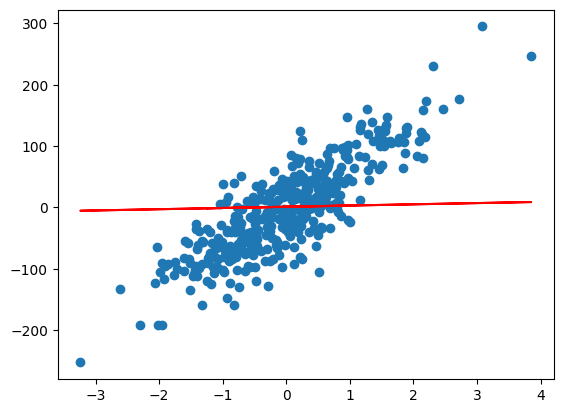

In [8]:
plt.scatter(X_train, y_train)
plt.plot(X_train, y_hat, c='r')

In [9]:
def cost_fun(y, y_hat):

  m = len(y)
  cost = 0

  for i in range(m):
    cost = cost + (y_hat[i] - y[i])**2

  cost = cost / (2 * m)

  return cost

In [10]:
cost_fun(y_train, y_hat)

array([2698.95481236])

In [11]:
def derivative(w, x, y, b, y_hat):

  m = len(x)

  dj_dw = 0
  dj_db = 0

  for i in range(m):

    dj_dw = dj_dw + (y_hat[i] - y[i]) * x[i]
    dj_db = dj_db + (y_hat[i] - y[i])

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [12]:
def gradient_descent(w, x, y, b, y_hat, derivative, alpha):


  dj_dw, dj_db = derivative(w, x, y, b, y_hat)

  w_temp = w - alpha * dj_dw
  b_temp = b - alpha * dj_db

  w = w_temp
  b = b_temp

  return w, b

In [13]:
def linear_regression(w, x, y, b, y_hat, derivative, gradient_descent, alpha, epochs):

  for i in range(epochs):

    y_hat = model(w, x, b)
    cost = cost_fun(y, y_hat)
    print(f'cost for epoch {i}: {cost}')
    w, b = gradient_descent(w, x, y, b, y_hat, derivative, alpha)
    print(f'w and b {w, b}')


  return w, b

In [14]:
w, b = linear_regression(w, X_train, y_train, b, y_hat, derivative, gradient_descent, alpha=0.1, epochs=100)

cost for epoch 0: [2698.95481236]
w and b (array([8.11104407]), array([0.77326605]))
cost for epoch 1: [2343.419908]
w and b (array([13.61945857]), array([0.55914203]))
cost for epoch 2: [2054.50880356]
w and b (array([18.58468677]), array([0.35735934]))
cost for epoch 3: [1819.73391824]
w and b (array([23.06030688]), array([0.16757834]))
cost for epoch 4: [1628.94882773]
w and b (array([27.09461086]), array([-0.01059486]))
cost for epoch 5: [1473.90924121]
w and b (array([30.73112616]), array([-0.17759429]))
cost for epoch 6: [1347.91632591]
w and b (array([34.0090859]), array([-0.33388227]))
cost for epoch 7: [1245.52692925]
w and b (array([36.96385264]), array([-0.47993949]))
cost for epoch 8: [1162.31814842]
w and b (array([39.62730038]), array([-0.6162568]))
cost for epoch 9: [1094.69605204]
w and b (array([42.02815879]), array([-0.74332845]))
cost for epoch 10: [1039.74027166]
w and b (array([44.19232345]), array([-0.86164659]))
cost for epoch 11: [995.07773496]
w and b (array([4

In [15]:
predicts = model(w, X_test, b)

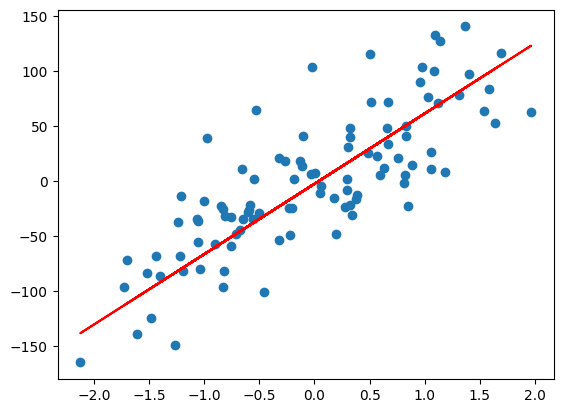

In [16]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predicts, c='r')

# **Create Dataset** (Multiple Linear Regression)

In [17]:
X, y = make_regression(n_samples=500, n_features=6, noise=20, random_state=42)

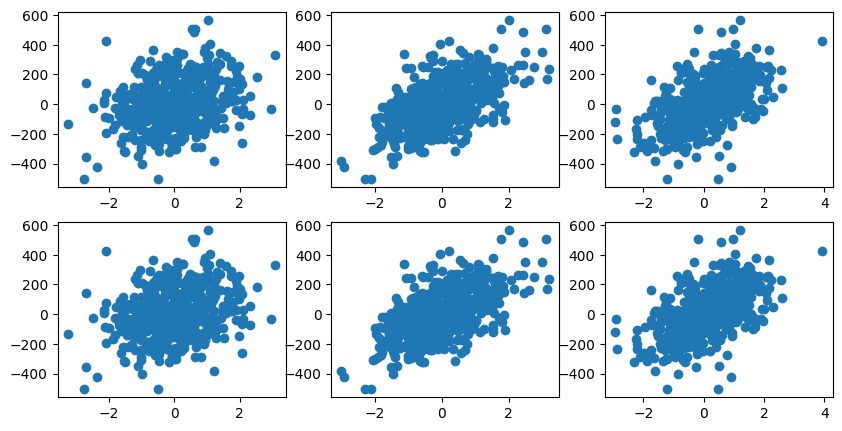

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))

for i in range(2):
  for j in range(3):
    axs[i][j].scatter(X[:, j], y)


# **Train Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 6)
(100, 6)
(400,)
(100,)


# **Multiple Linear Regression**

In [32]:
def model_mlr(w, x, b):

  m = len(x)
  y_hat = []

  for i in range(m):
    f_wb = np.dot(w, x[i]) + b
    y_hat.append(f_wb)

  return y_hat

In [33]:
w = np.array([2, 1, 4, 3, 5, 8])
b = 10

y_hat = model_mlr(w, X_train, b)

In [34]:
def cost_mlr(y, y_hat):

  m = len(y)
  cost_multiple = 0

  for i in range(m):
    cost_multiple = cost_multiple + (y_hat[i] - y[i])**2

  cost = cost_multiple / (2 * m)

  return cost

In [35]:
X_train.shape

(400, 6)

In [36]:
def derivative_mlr(x, w, b, y, y_hat):

  m = x.shape[0]
  n = x.shape[1]

  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    for j in range(len(dj_dw)):

      dj_dw[j] = (y_hat[i] - y[i]) * x[i][j]

    dj_db = dj_db + (y_hat[i] - y[i])

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [37]:
dj_dw, dj_db = derivative_mlr(X_train, w, b, y, y_hat)

In [38]:
print(dj_dw)

[-0.11700819 -0.05136222  0.39513522 -0.03788973  0.09704262  0.44096731]


In [39]:
def gradient_descent_mlr(x, w, b, y, y_hat, derivative_mlr, alpha):

  dj_dw, dj_db = derivative_mlr(x, w, b, y, y_hat)

  w_temp = w - alpha * dj_dw
  b_temp = b - alpha * dj_db

  w = w_temp
  b = b_temp

  return w, b


In [41]:
gradient_descent_mlr(X_train, w, b, y_train, y_hat, derivative_mlr, alpha=0.1)

(array([1.97815962, 0.99041289, 4.07375468, 2.99292762, 5.01811367,
        8.08230956]),
 np.float64(10.18187549877387))

In [54]:
def multiple_linear_regression(x, y, w, b, derivative_mlr, gradient_descent_mlr, alpha, epochs):

  for i in range(epochs):
    y_hat = model_mlr(w, x, b)
    cost_lr = cost_mlr(y, y_hat)
    print(f'Cost for epoch {i}: {cost_lr}')
    w, b = gradient_descent_mlr(x, w, b, y, y_hat, derivative_mlr, alpha)

  return w, b

In [55]:
multiple_linear_regression(X_train, y_train, w, b, derivative_mlr, gradient_descent_mlr, alpha=0.1, epochs=100)

Cost for epoch 0: 12987.556322139058
Cost for epoch 1: 12971.360609566073
Cost for epoch 2: 12956.88107360876
Cost for epoch 3: 12943.799150682386
Cost for epoch 4: 12931.856473650478
Cost for epoch 5: 12920.843466273736
Cost for epoch 6: 12910.590101581718
Cost for epoch 7: 12900.958413322047
Cost for epoch 8: 12891.83642767655
Cost for epoch 9: 12883.13324564154
Cost for epoch 10: 12874.775057671337
Cost for epoch 11: 12866.701913659479
Cost for epoch 12: 12858.865104928265
Cost for epoch 13: 12851.22504211228
Cost for epoch 14: 12843.749534867315
Cost for epoch 15: 12836.412397194465
Cost for epoch 16: 12829.192316635968
Cost for epoch 17: 12822.071937318293
Cost for epoch 18: 12815.037116312278
Cost for epoch 19: 12808.076320470196
Cost for epoch 20: 12801.180137131067
Cost for epoch 21: 12794.340877132732
Cost for epoch 22: 12787.552252658528
Cost for epoch 23: 12780.809115759688
Cost for epoch 24: 12774.107246078933
Cost for epoch 25: 12767.443178475127
Cost for epoch 26: 12760.8

(array([-0.06543554,  0.09335106, 12.97495063,  2.33116821,  6.71300209,
        11.78398143]),
 np.float64(11.406617636320965))